# Class 01: Cross-validation, data leakage and overfitting

For this practical session we will use a public dataset on dairy cows health monitoring from Wang et al. (2022) During the prenatal transition period, parity, body condition score (BCS), dystocia score (DS), daily rumination time (DRT), daily activity (DA), and date of calving were collected and used as prenatal indicators. During the postpartum transition period, the β-hydroxybutyrate concentration in blood (bBHB) was collected from cows and this parameter was used to determine if the cow had ketosis. In this study, a total of 312 Chinese Holstein cows were recorded.

In this paper the focus was a classification task for ketosis, we will however use the dataset for regression.

[Wang et al. (2022)](https://www.sciencedirect.com/science/article/pii/S0168169923000856#s0165)

# Libraries

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import learning_curve   
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.dummy import DummyRegressor
import seaborn as sns

# Read data

In [2]:
df_data = pd.read_excel('../data/raw/wang_et_al_2022.xlsx', index_col=0)  

# Selecting data

In this practical session, we will aim to predict blood BHB concentration on day 19 after calving using pre-calving activity data, general animal characteristics, and blood measurements collected 3 days after calving. Although a prediction model based exclusively on non-invasive pre-calving features would be the most valuable from a practical standpoint, we adopt this broader approach for two reasons:

-It obviously allows substantially better predictive performance and model fitting, which allows us better to demonstrate the overfitting.

-From a data science perspective, integrating heterogeneous datasets with missing values is a common and important challenge. Developing accurate imputation models for missing measurements is an important task in data mining.

In [3]:
# select only the columns that are needed for the model
df_data = df_data[['Daily rumination time', 'Daily activity', 'bBHBmol/L(4d)', 'bBHBmol/L(9d)', 'bBHBmol/L(14d)', 'BCS', 'Parity', 'Season', 'DystociaScore',
                   'bBHBmol/L(19d)']]

# Data exploration

**TASK**
Check the types of the columns in the DataFrame.

In [4]:
# Add your code here

**TASK**
Make a corelation plot.

In [6]:
# Add your code here

BCS, Parity and DystociaScore are ordinal features and already in the correct order: for these variables we can keep the variables as int. 
Season should be converted to a categorical feature. We could this directly, however we will do this later in a pipeline.

# Train - test split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(df_data.drop(columns = 'bBHBmol/L(19d)'), 
                                                    df_data['bBHBmol/L(19d)'], test_size=0.2, random_state=65461) 

# Modeling

To avoid data leakage, scaling should always be fitted on the training data and then applied to the test data. However, when using cross-validation, scaling the entire training set beforehand can still introduce leakage, as information from the validation folds is used during scaling. For this reason, it is recommended to use pipelines, which ensure that scaling is performed separately within each training fold during cross-validation.

In [9]:
# Define feature groups
numeric_features = ['Daily rumination time', 'Daily activity', 'bBHBmol/L(4d)', 'bBHBmol/L(9d)', 'bBHBmol/L(14d)']
categorical_features = ['Season']

# Keep ordinal features as integers (passthrough)
ordinal_features = ['BCS', 'Parity', 'DystociaScore']

**TASK**
Construct a pipeline where Season is converted to a categorical variable and where the following features are scaled.
First build the preprocessing pipeline "preprocessor" for the numeric and categorical features using ColumnTransformer()

In [10]:
# Add your code here

# preprocessor = 


**TASK**
Now built the full pipeline with the model (GradientBoostingRegressor) and the preprocessor and evaluate the R2 and RMSE on train and test set. Assign the pipeline to gbm_pipeline_1.

For model parameters use the params below, this allows a heavily overtrained model.

In [12]:
params = {'n_estimators': 1000, 'max_depth': 10, 'min_samples_split': 2,
          'learning_rate': 0.01, 'loss': 'squared_error'}

In [13]:
# Add your code here

# gbm_1 = Pipeline(

**TASK**
Perform a quick 5 fold CV estimate on the training set using cross_val_score() and evaluate the mean and standard deviation of the R2 and RMSE scores

In [15]:
# Put your code here

**TASK**
In the model above, we used a fixed set of hyperparameters. One important hyperparameter is the learning rate, which determines how strongly each new tree contributes to the model. Higher learning rates can improve training performance quickly but may increase the risk of overfitting, while lower learning rates generally lead to better generalization but require more trees.

Assess the influence of the learning rate by evaluating model performance for different learning rate values. Compare both training and test performance to identify signs of overfitting. Keep in mind that tuning hyperparameters based on test set performance introduces data leakage. Therefore, in the next coding block, we will perform a more appropriate evaluation using cross-validation.

In [17]:
# Add your code here

# learning_rates = [(...)]

# for lr in learning_rates:
#     params = {
#         'n_estimators': 1000,
#         'max_depth': 10,
#         'min_samples_split': 2,
#         'learning_rate': lr,
#         'loss': 'squared_error'
#     }
#     (...)

## Tuning and CV

To evaluate how well the model generalizes to new data, we will use cross-validation (CV) for model tuning. To save time during this practical session, we have limited the number of tuning iterations.

**TASK**
Perform a 5 fold CV with 100 iterations for tuning based on the next random grid. You can use the same pipeline and use RandomizedSearchCV on this pipeline.

In [19]:
n_estimators = [int(x) for x in np.linspace(start=100, stop=1000, num=50)]
learning_rate = [x for x in np.logspace(start=-3, stop=-0.01, num=50)]
max_features = ['sqrt', 'log2', None]
max_depth = [int(x) for x in np.linspace(1, 10, num=10)]
min_samples_split = [2, 5, 10, 30]
min_samples_leaf = [1, 2, 4, 10, 30]
subsample = [0.4, 0.6, 0.8, 1]

random_grid = {
    'model__n_estimators': n_estimators,
    'model__learning_rate': learning_rate,
    'model__max_features': max_features,
    'model__max_depth': max_depth,
    'model__min_samples_split': min_samples_split,
    'model__min_samples_leaf': min_samples_leaf,
    'model__subsample': subsample,
}

gbm_pipeline = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('model', GradientBoostingRegressor(random_state=4872))
    ]
)

In [20]:
# Add your code here

**TASK**
Refit the best model (assign to gbm_2) and evaluate the performance on train and test set.

In [22]:
params = gbm_random.best_params_

gbm_2 = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('model', GradientBoostingRegressor(**params))
    ]
)

gbm_2.fit(X_train, y_train)

y_pred_train = gbm_2.predict(X_train)
y_pred_test = gbm_2.predict(X_test)

print('R2 (Train): %.3f' % r2_score(y_train, y_pred_train))
print('RMSE (Train): %.3f' % np.sqrt(mean_squared_error(y_train, y_pred_train)))
print('R2 (Test): %.3f' % r2_score(y_test, y_pred_test))
print('RMSE (Test): %.3f' % np.sqrt(mean_squared_error(y_test, y_pred_test)))

R2 (Train): 0.889
RMSE (Train): 0.154
R2 (Test): 0.761
RMSE (Test): 0.261


## Learning curve

A learning curve shows how a model's performance changes as it is trained on increasing amounts of data or over additional training iterations. It is a useful tool for assessing whether a model is learning effectively and for identifying potential issues such as underfitting or overfitting. In this work, the learning curve is computed using cross-validation on the training set, which also provides an indication of the variability and uncertainty in the model's performance.

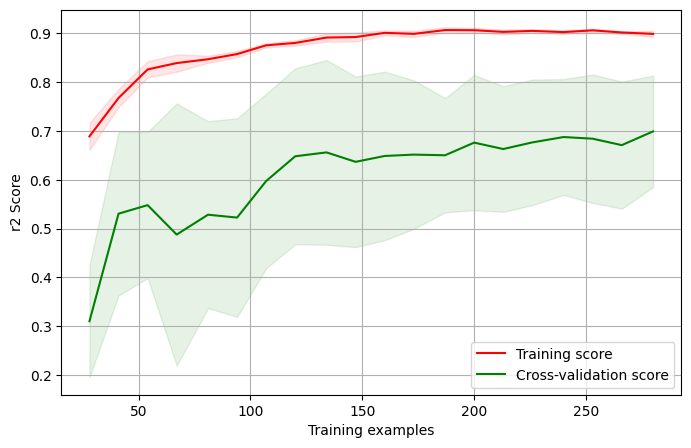

In [23]:
def plot_learning(clf, x_train, y_train, cv, num_show, metric=None ):
    train_sizes, train_scores, test_scores = learning_curve(clf,
                                                                   X=x_train, y = y_train, cv=cv, 
                                                                   n_jobs=None,  scoring = metric,                                                            
                                                                   return_times=False,
                                                                   train_sizes = np.linspace(0.1, 1.0, num_show)                                                          
                                                           )
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(8, 5))
    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                         train_scores_mean + train_scores_std, alpha=0.1,
                         color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1,
                         color="g")
    plt.plot(train_sizes, train_scores_mean, color="r",label="Training score")
    plt.plot(train_sizes, test_scores_mean, color="g",label="Cross-validation score")
    plt.ylabel( str(metric) + ' Score')
    plt.xlabel("Training examples")
    plt.legend(loc="best")
    return
plot_learning(gbm_2, df_data.drop(columns=['bBHBmol/L(19d)']), df_data['bBHBmol/L(19d)'], 10, metric = "r2", num_show = 20)
plt.show()

**TASK**
Compare this learning curve with that of the first heavily overfitted model by again evaluating the model on the training set using cross-validation. Ideally, overfitting should be detected during the training process rather than afterwards when the model is evaluated on the test set. Repeatedly evaluating the model on the test set and adapting it accordingly is a poor strategy, as it leads to overly optimistic estimates of the model's generalization performance.

In [24]:
# Add your code here

## Performance Summary

A compact comparison makes the main lesson easier to read: the tuned pipeline should outperform the dummy baseline, while the overfit model should show the largest train-test gap.

In [ ]:
# Baseline: predict the training mean
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)

baseline_train_pred = baseline.predict(X_train)
baseline_test_pred = baseline.predict(X_test)

# Reuse the already trained models
model_summary = pd.DataFrame([
    {
        'Model': 'Dummy baseline',
        'Train R2': r2_score(y_train, baseline_train_pred),
        'Test R2': r2_score(y_test, baseline_test_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, baseline_train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, baseline_test_pred)),
    },
    {
        'Model': 'Overfit GBM',
        'Train R2': r2_score(y_train, gbm_1.predict(X_train)),
        'Test R2': r2_score(y_test, gbm_1.predict(X_test)),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, gbm_1.predict(X_train))),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, gbm_1.predict(X_test))),
    },
    {
        'Model': 'Tuned GBM',
        'Train R2': r2_score(y_train, gbm_2.predict(X_train)),
        'Test R2': r2_score(y_test, gbm_2.predict(X_test)),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, gbm_2.predict(X_train))),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, gbm_2.predict(X_test))),
    },
]).round(3)

print(model_summary.to_string(index=False))